In [1]:
import gdsfactory as gf
import numpy as np
import math

gf.gpdk.PDK.activate()

In [2]:
def n_SiN (wavelength):

    return np.sqrt(1+(2.9144*wavelength**2)/(wavelength**2-0.1366**2)+(0.004873)/(wavelength**2-1.6606**2))


def n_SiO2 (wavelength):

    return np.sqrt(1+(1.1056*wavelength**2)/(wavelength**2-0.078**2)+(2.360*wavelength**2)/(wavelength**2-16.681**2)) + 0.002

In [3]:
print(f"core = {n_SiN(1.310)}")
print(f"cladd = {n_SiO2(1.310)}")


core = 1.9853862205517132
cladd = 1.449372899031811


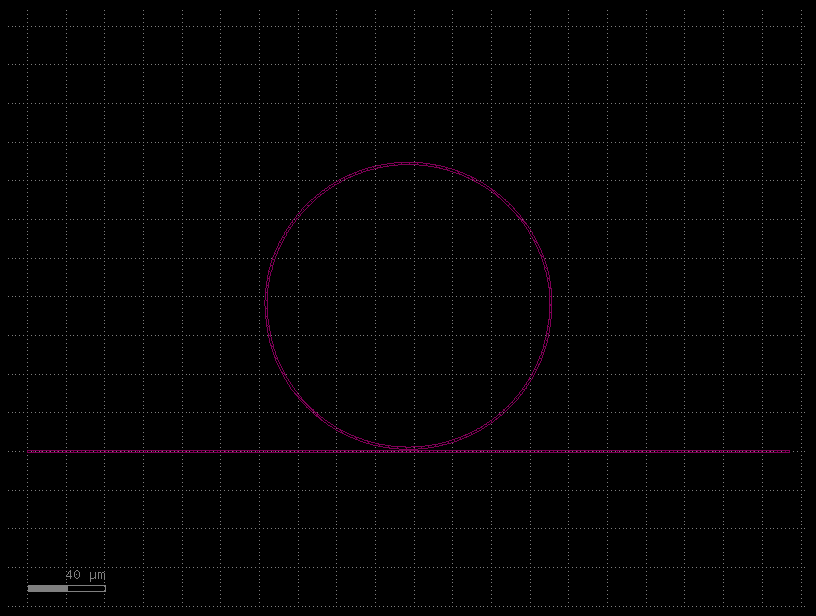

In [4]:
def All_pass_ring(wavelength = 1.310,
                  core_material= 0,
                  cladd_material= 0,
                  neff= 1.574385, # for 1.2 um width, 220nm thick at 1310nm SiN
                  ng = 1.855907, # Group index of Silicon and
                  FSR = 20,
                  strip_length = 400,
                  RR_pos = (0,0),
                  gap = 0.150,
                  wg_width_strp = 1.2,
                  thickness = 0.22,
                  layer = (733,727),):



    strip_length = 500-53*2

    ## Cálculo del delta de L

    R = 1000 * (wavelength)**2 / (2*math.pi*FSR*ng)  ##um

    ## For phase-match with the wavelength

    m = neff*2*math.pi*R/wavelength

    new_R = round(m) * wavelength/(neff*2*math.pi)

    new_FSR = 1000 * (wavelength)**2 / (2*math.pi*new_R*ng)


    # //////  INICIO DE LA FUNCIÓN
    # We define an sketch where we will place the components
    c = gf.Component()


    # ######BOX, IN#######
    #
    # box_poly = gf.Component()
    #
    # box_poly.add_polygon([(0,13),(53,13),(53,-13),(0,-13)], layer= (1328,1609))
    # box_in_ref = c.add_ref(box_poly)
    #
    # box_in_ref.move((RR_pos[0]-53,RR_pos[1]))
    #
    #
    # ###################



    ############## BUS SiN ###################

    cross_strip_wg = gf.cross_section.strip(
    width=wg_width_strp,
    layer=layer
    )

    STRP_SiN_in = gf.components.straight(length=strip_length,cross_section=cross_strip_wg)
    STRP_SiN_in_ref = c.add_ref(STRP_SiN_in)
    STRP_SiN_in_ref.move((RR_pos[0],RR_pos[1]))

    ###############################################


    ##############    Ring   #######################

    ring = gf.components.rings.ring(radius=new_R, width=wg_width_strp, angle_resolution=2.5, layer=layer, angle=360).copy()
    ring_ref = c.add_ref(ring)
    ring_ref.move((RR_pos[0] + strip_length/2 , RR_pos[1] + new_R + wg_width_strp + gap ))

    #################################################

    # # Create text
    # text = gf.components.text(
    #     text=f"AP_FSR_{new_FSR:.4f}nm_R_{new_R:.2f}um_Juanes",
    #     size=5,          # height in microns
    #     layer=layer
    # )
    #
    # # Add to layout
    # text_ref = c.add_ref(text)
    #
    # # Move it if needed
    # text_ref.move((RR_pos[0] + 20, RR_pos[1] + 20))



    total_x_length = abs(STRP_SiN_in_ref.ports["o1"].center[0] - STRP_SiN_in_ref.ports["o2"].center[0] ) ## um
    total_y_length = 3*wg_width_strp + gap + 2*new_R   ## um


    # ######BOX, OUT#######
    #
    # box_poly_out = gf.Component()
    #
    # box_poly_out.add_polygon([(0,13),(53,13),(53,-13),(0,-13)], layer= (1328,1609))
    # box_out_ref = c.add_ref(box_poly_out)
    #
    # box_out_ref.move((RR_pos[0] + total_x_length,RR_pos[1]))
    #
    #
    # ###################



    return c, total_x_length,total_y_length

RR_scketch = gf.Component()

y_pos = 0

for fsr in    [2.0]:
    # [6.0,7.0,8.0,9.0,9.5,10,10.2,10.5]:
    RR = All_pass_ring(gap = 0.500 ,FSR = fsr ,RR_pos=(0,y_pos))
    RR_scketch.add_ref(RR[0])
    y_pos += RR[2] + 20


RR_scketch.draw_ports()
RR_scketch.plot()
RR_scketch.write("RR_SiN_Juanes_1.gds")
RR_scketch.show()